In [1]:
# This notebook investigates and visualizes the training of trajectory model, while experimenting the effect of coupling and decoupling distribution \pi
import numpy as np 
import torch.nn as nn 
from sklearn.datasets import make_swiss_roll,\
     make_moons, make_gaussian_quantiles, make_circles, make_blobs 
import torch 
import matplotlib.pyplot as plt 
import matplotlib.animation as animation
from matplotlib.collections import LineCollection


In [2]:
class FlowModel(nn.Module):
  def __init__(self, input_dim, ffn_dim, output_dim):
    super(FlowModel, self).__init__() 
    self.input_dim = input_dim 
    self.output_dim = output_dim 
    self.ffn_dim = ffn_dim 
    self.model = nn.Sequential(
      nn.Linear(input_dim + 1, ffn_dim), 
      nn.ELU(), 
      nn.Linear(ffn_dim, ffn_dim), 
      nn.ELU(), 
      nn.Linear(ffn_dim, ffn_dim), 
      nn.ELU(), 
      nn.Linear(ffn_dim, output_dim)
    )
  
  def forward(self, x_t, t): 
    return self.model(torch.cat((x_t, t), dim = -1))

  def step(self, x_t, t_0, t_1):
   t_0 = t_0.view(1, 1).expand(x_t.shape[0], 1) 
   return x_t + (t_1 - t_0) * self(x_t = x_t, t = t_0) 

In [3]:
'''
Borrowed from :
https://github.com/helblazer811/Diffusion-Explorer/blob/0dcfab92b2898f77553257c3642eb8c3aaf31f9a/diffusion-explor\
    er/apps/continuity-equation-explainer/scripts/generate_smiley_face.py#L15
'''
def make_smiley_face(num_samples: int = 400) -> np.ndarray:
    """
    Create smiley face distribution by sampling from Gaussians.

    - Eyes: Two Gaussians at top of face (negative y in screen coords)
    - Nose: Single Gaussian in center
    - Mouth: Sequence of Gaussians along a curved arc at bottom (positive y)

    Returns array of shape (num_samples, 2).
    """
    samples = []

    # Feature parameters (will be scaled up at the end)
    eye_std = 0.04   # Tighter eyes
    nose_std = 0.04  # Tighter nose
    mouth_std = 0.04  # Tighter mouth

    # Positions (y negative = top, y positive = bottom in screen coords)
    # Eyes closer together
    left_eye_pos = np.array([-0.35, -0.6])
    right_eye_pos = np.array([0.35, -0.6])
    nose_pos = np.array([0.0, -0.15])  # Shifted up (more negative y)

    # Mouth arc parameters
    mouth_center_y = 0.5  # Center of mouth arc
    mouth_radius = 0.6    # Radius of the arc
    mouth_arc_start = 0.2 * np.pi  # Start angle (radians from horizontal) - wider
    mouth_arc_end = 0.8 * np.pi    # End angle - wider
    num_mouth_gaussians = 12       # Number of Gaussians along the arc

    # Weights for each feature (determines proportion of samples)
    eye_weight = 1.0
    nose_weight = 0.5
    mouth_weight = 3.0  # More samples for the mouth since it's larger

    total_weight = 2 * eye_weight + nose_weight + mouth_weight

    # Calculate number of samples for each feature
    n_per_eye = int(num_samples * eye_weight / total_weight)
    n_nose = int(num_samples * nose_weight / total_weight)
    n_mouth = num_samples - 2 * n_per_eye - n_nose

    # Sample eyes
    left_eye_samples = np.random.normal(left_eye_pos, eye_std, (n_per_eye, 2))
    right_eye_samples = np.random.normal(right_eye_pos, eye_std, (n_per_eye, 2))
    samples.extend(left_eye_samples)
    samples.extend(right_eye_samples)

    # Sample nose
    nose_samples = np.random.normal(nose_pos, nose_std, (n_nose, 2))
    samples.extend(nose_samples)

    # Sample mouth along arc
    # Generate positions along the arc
    angles = np.linspace(mouth_arc_start, mouth_arc_end, num_mouth_gaussians)
    mouth_centers = []
    for angle in angles:
        x = mouth_radius * np.cos(angle)
        y = mouth_center_y + mouth_radius * np.sin(angle) - mouth_radius  # Shift down
        mouth_centers.append(np.array([x, y]))

    # Sample from each mouth Gaussian
    samples_per_mouth_gaussian = n_mouth // num_mouth_gaussians
    remainder = n_mouth % num_mouth_gaussians

    for i, center in enumerate(mouth_centers):
        n = samples_per_mouth_gaussian + (1 if i < remainder else 0)
        mouth_samples = np.random.normal(center, mouth_std, (n, 2))
        samples.extend(mouth_samples)

    samples = np.array(samples)

    # Mean center the samples
    mean = samples.mean(axis=0)
    samples = samples - mean
    std = samples.std()
    samples = samples / std

    scale_factor = 1.4
    samples = samples * scale_factor

    return samples * (-1)

def get_mixture_of_gaussian(num_samples : int = 400) -> np.ndarray:
    samples = []

    # Feature parameters (will be scaled up at the end)
    component_1_std = 0.04
    component_2_std = 0.04

    component_1_mean = np.array([3.0,  2.0])
    component_2_mean = np.array([3.0, -2.0])

    # Sample eyes
    component_1_samples = np.random.normal(component_1_mean, component_1_std,  (num_samples // 2, 2))
    component_2_samples = np.random.normal(component_2_mean, component_2_std, (num_samples // 2, 2))
    samples.extend(component_1_samples)
    samples.extend(component_2_samples)

    samples = np.array(samples)

    # # Mean center the samples
    # mean = samples.mean(axis = 0)
    # samples = samples - mean
    # std = samples.std()
    # samples = samples / std

    # scale_factor = 1.4
    # samples = samples * scale_factor

    return samples


def get_dataset_samples(dataset = 'blobs', n_samples = 2000, random_state = 42, **kwargs):
 defaults = {
  'blobs' : dict(n_features = 2, centers = 3, cluster_std = 0.5),
  'moons' : dict(noise = 0.05),
  'circles': dict(noise = 0.05, factor = 0.5),
  'swiss_roll': dict(noise = 0.1),
  'gaussian_quantiles':  dict(n_features = 2, n_classes = 3),
 }

 makers = {
  'blobs':              make_blobs,
  'moons':              make_moons,
  'circles':            make_circles,
  'swiss_roll':         make_swiss_roll,
  'gaussian_quantiles': make_gaussian_quantiles,
 }

 if dataset not in makers:
  raise ValueError(f"Unknown dataset '{dataset}'. "
                         f"Choose from: {list(makers.keys())}")

 params = {**defaults[dataset], **kwargs}
 X, y = makers[dataset](n_samples=n_samples, random_state=random_state, **params)

    # swiss_roll returns 3D; keep only the 2 spread dimensions
 if dataset == 'swiss_roll':
   X = X[:, [0, 2]]

 X = torch.tensor(X, dtype = torch.float32)
 y = torch.tensor(y, dtype = torch.long)
 return X, y 

In [4]:
net = FlowModel(input_dim = 2, output_dim = 2, ffn_dim = 64)
optimizer = torch.optim.Adam(net.parameters(), lr = 1e-2)
num_epochs = 10000
loss_fn   = nn.MSELoss()
n_samples = 2000 
n_features = 2
random_state = 42
cluster_std = 0.5 
centers = 3


# Training decouple flow (independent) 
for i in range(num_epochs):
    x_1 = torch.tensor(make_smiley_face(n_samples), dtype = torch.float32)
    
    t = torch.rand(len(x_1), 1)
    x_0 = torch.randn_like(x_1)
    x_t = x_1 * t + x_0 * (1 - t)
    dx_t     = x_1 - x_0
    optimizer.zero_grad()
    net_out  = net(x_t, t)
    loss     = loss_fn(net_out, dx_t)
    loss.backward()
    optimizer.step()

    if i % 100 == 0: 
       print(f"step {i} | loss: {loss.item():.4f}")



step 0 | loss: 2.9358
step 100 | loss: 1.8634
step 200 | loss: 1.9167
step 300 | loss: 1.8014
step 400 | loss: 1.8632
step 500 | loss: 1.8252
step 600 | loss: 1.7923
step 700 | loss: 1.7901
step 800 | loss: 1.8239
step 900 | loss: 1.7675
step 1000 | loss: 1.8063
step 1100 | loss: 1.7730
step 1200 | loss: 1.7978
step 1300 | loss: 1.8135
step 1400 | loss: 1.7122
step 1500 | loss: 1.8869
step 1600 | loss: 1.7677
step 1700 | loss: 1.7627
step 1800 | loss: 1.7804
step 1900 | loss: 1.8811
step 2000 | loss: 1.7581
step 2100 | loss: 1.7886
step 2200 | loss: 1.7692
step 2300 | loss: 1.7798
step 2400 | loss: 1.6933
step 2500 | loss: 1.8040
step 2600 | loss: 1.9019
step 2700 | loss: 1.8648
step 2800 | loss: 1.7805
step 2900 | loss: 1.7811
step 3000 | loss: 1.7373
step 3100 | loss: 1.7887
step 3200 | loss: 1.7662
step 3300 | loss: 1.8299
step 3400 | loss: 1.7805
step 3500 | loss: 1.7242
step 3600 | loss: 1.8354
step 3700 | loss: 1.7521
step 3800 | loss: 1.7425
step 3900 | loss: 1.7370
step 4000 | 

In [5]:
rectified_net = FlowModel(input_dim = 2, output_dim = 2, ffn_dim = 64)
rec_optimizer = torch.optim.Adam(rectified_net.parameters(), lr = 1e-2)
num_epochs = 10000
loss_fn   = nn.MSELoss()
n_samples = 2000
n_steps = 20
time_steps = torch.linspace(0, 1.0, n_steps + 1)

def samples(x_0): 
  x = x_0
  with torch.no_grad():
    for i in range(n_steps):
      x = net.step(x, time_steps[i], time_steps[i + 1])
    return x 

# Training coupling flow (higher degree of dedependent) 
for i in range(num_epochs):
    #x_1 = torch.tensor(make_moons(n_samples = 2000, noise = 0.05)[0], dtype = torch.float32)
    t = torch.rand(len(x_1), 1)
    x_0 = torch.randn((n_samples, 2))
    x_1 = samples(x_0)
    x_t = x_0 * (1 - t) + t * x_1 
    dx_t     = x_1 - x_0
    rec_optimizer.zero_grad()
    rec_net_out  = rectified_net(x_t, t)
    loss = loss_fn(rec_net_out, dx_t)
    loss.backward()
    rec_optimizer.step()

    if i % 100 == 0: 
       print(f"step {i} | loss: {loss.item():.4f}")



step 0 | loss: 0.4130
step 100 | loss: 0.0468
step 200 | loss: 0.0252
step 300 | loss: 0.0142
step 400 | loss: 0.0094
step 500 | loss: 0.0073
step 600 | loss: 0.0064
step 700 | loss: 0.0067
step 800 | loss: 0.0051
step 900 | loss: 0.0039
step 1000 | loss: 0.0040
step 1100 | loss: 0.0028
step 1200 | loss: 0.0035
step 1300 | loss: 0.0028
step 1400 | loss: 0.0027
step 1500 | loss: 0.0025
step 1600 | loss: 0.0027
step 1700 | loss: 0.0026
step 1800 | loss: 0.0028
step 1900 | loss: 0.0057
step 2000 | loss: 0.0027
step 2100 | loss: 0.0022
step 2200 | loss: 0.0019
step 2300 | loss: 0.0016
step 2400 | loss: 0.0021
step 2500 | loss: 0.0048
step 2600 | loss: 0.0017
step 2700 | loss: 0.0021
step 2800 | loss: 0.0024
step 2900 | loss: 0.0012
step 3000 | loss: 0.0015
step 3100 | loss: 0.0017
step 3200 | loss: 0.0019
step 3300 | loss: 0.0031
step 3400 | loss: 0.0014
step 3500 | loss: 0.0021
step 3600 | loss: 0.0013
step 3700 | loss: 0.0013
step 3800 | loss: 0.0013
step 3900 | loss: 0.0012
step 4000 | 

In [6]:
def visualizing_flow_path(trajectories, rectifed, num_samples, num_steps, fps, duration):
  idx = np.random.choice(trajectories.shape[1], num_samples, replace = False)
  trajs = trajectories[:, idx, :]
  T = trajs.shape[0]

  xall = trajs[:, :, 0]
  yall = trajs[:, :, 1]

  fig, ax = plt.subplots(figsize = (7, 7), facecolor = '#ffffff')
  ax.set_facecolor('#ffffff')
  ax.axis('off')

  ax.set_xlim(xall.min() - 0.3, xall.max() + 0.3)
  ax.set_ylim(yall.min() - 0.3, yall.max() + 0.3)

  for i in range(num_samples):
    ax.plot(trajs[:, i, 0], trajs[:, i, 1], color = '#c0c0c0', alpha = 0.35, lw = 0.5, zorder = 1)

  def pcolor(t_frac, alpha=1.0):
    r = 224 + (74  - 224) * t_frac
    g =  90 + (144 -  90) * t_frac
    b =  58 + (217 -  58) * t_frac
    return (r / 255, g / 255, b / 255, alpha)

  trail_lines = []
  for i in range(num_samples):
    lc = LineCollection([], linewidths=1.2, zorder=2)
    ax.add_collection(lc)
    trail_lines.append(lc)


  dots,  = ax.plot([], [], 'o', ms = 4, zorder = 4, color = '#333333')
  halos, = ax.plot([], [], 'o', ms = 10, zorder = 3, color = '#333333', markerfacecolor = 'none', markeredgewidth = 1.2)

  y_prog = yall.min() - 0.15

  progress_bg = ax.axhline(y = y_prog, xmin = 0, xmax = 1, color = '#dddddd', alpha = 1.0, lw = 3)
  progress_ln = ax.axhline(y = y_prog, xmin = 0, xmax = 0, color = '#4a90d9', alpha = 0.8, lw = 3)


  time_txt = ax.text(0.03, 0.96, '', transform = ax.transAxes, color = '#555555', fontsize = 10, alpha = 0.8, va = 'top')

  total_frames = fps * duration

  def update(frame):
      t_frac = frame / (total_frames - 1)
      step = t_frac * (T + 1)
      lo_s = int(step)
      frac = step - lo_s

      cur = trajs[-1] if lo_s >= T - 1 else trajs[lo_s] * (1 - frac) + trajs[lo_s + 1] * frac

      trail_start = max(0, lo_s - num_steps)
      for i, lc in enumerate(trail_lines):
          pts = trajs[trail_start : lo_s + 1, i, :]
          if len(pts) < 2:
              lc.set_segments([])
              continue
          segs   = [pts[k : k + 2] for k in range(len(pts) - 1)]
          alphas = np.linspace(0.05, 0.6, len(segs))
          lc.set_segments(segs)
          lc.set_colors([pcolor(t_frac, a) for a in alphas])

      dots.set_data(cur[:, 0], cur[:, 1])
      dots.set_color(pcolor(t_frac, 0.95))
      halos.set_data(cur[:, 0], cur[:, 1])
      halos.set_color(pcolor(t_frac, 0.45))  

      progress_ln.set_xdata([0, t_frac])
      time_txt.set_text(f't = {t_frac:.2f}')

      return trail_lines + [dots, halos, progress_ln, time_txt]

  ani = animation.FuncAnimation(fig, update, frames = total_frames, interval = 1000 / fps, blit = True)
  ani.save(f'gif/{'re' if rectifed else ''}flow_particles.gif', writer = 'pillow', fps = fps, dpi = 120)
  plt.show()

In [7]:
def visualize_vector_field(trajectories, rectifed, num_samples, num_steps, fps, duration, grid_n, time_steps):
  idx = np.random.choice(trajectories.shape[1], num_samples, replace = False)
  trajs = trajectories[:, idx, :]
  T = trajs.shape[0]

  def field_velocity(grid_xy, t_frac):
    t_idx = min(int(t_frac * (T - 1)), T - 2)
    dt  = time_steps[1] - time_steps[0]
    cur = trajs[t_idx]
    nxt = trajs[t_idx + 1]
    vel_pts = (nxt - cur) / dt
    diff = grid_xy[:, None, :] - cur[None, :, :]
    w = np.exp(-(diff ** 2).sum(-1) / 0.9)
    w_sum = w.sum(-1, keepdims = True) + 1e-8
    return (w[:, :, None] * vel_pts[None]).sum(1) / w_sum

  def pcolor(t):
    r = 224 + (74  - 224) * t
    g =  90 + (144 -  90) * t
    b =  58 + (217 -  58) * t
    return np.array([r, g, b]) / 255

  xall = trajs[:, :, 0]
  yall = trajs[:, :, 1]
  xlo, xhi = xall.min() - 0.4, xall.max() + 0.4
  ylo, yhi = yall.min() - 0.4, yall.max() + 0.4

  fig, ax = plt.subplots(figsize=(7, 7), facecolor = '#ffffff')
  ax.set_facecolor('#ffffff')
  ax.axis('off')
  ax.set_xlim(xlo, xhi)
  ax.set_ylim(ylo, yhi)


  gx = np.linspace(xlo, xhi, grid_n)
  gy = np.linspace(ylo, yhi, grid_n)
  GX, GY = np.meshgrid(gx, gy)
  grid_xy = np.stack([GX.ravel(), GY.ravel()], axis=1)

  Q = ax.quiver(GX, GY, np.zeros_like(GX), np.zeros_like(GY), np.zeros(GX.size), cmap='plasma', clim=(0, 3), \
      scale = grid_n * 2.2, width = 0.003, headwidth = 4, headlength = 5, alpha = 0.55, zorder = 2)


  dots,  = ax.plot([], [], 'o', ms = 4, zorder = 5, color = '#333333')


  time_txt = ax.text(0.03, 0.96, '', transform = ax.transAxes, color = '#555555', fontsize = 10, alpha = 0.8, va = 'top')

  total = fps * duration 

  def update(frame):
      tf = frame / (total - 1)
      step = tf * (T + 1)
      lo = int(step)
      al  = step - lo

      cur = trajs[-1] if lo >= T - 1 else trajs[lo] * (1 - al) + trajs[lo + 1] * al
      ts = max(0, lo - num_steps)

      c = pcolor(tf)
      dots.set_data(cur[:, 0], cur[:, 1])
      dots.set_color((*c, 0.95))

      fv = field_velocity(grid_xy, tf)
      U, V  = fv[:, 0].reshape(grid_n, grid_n), fv[:, 1].reshape(grid_n, grid_n)
      speed = np.sqrt(U ** 2 + V ** 2) + 1e-8
      Q.set_UVC(U / speed, V / speed, speed)

      dt_p  = 1e-3
      tf2   = min(1.0, tf + dt_p)
      s2    = tf2 * (T - 1); lo2 = int(s2); a2 = s2 - lo2
      nxt   = trajs[-1] if lo2 >= T - 1 else trajs[lo2] * (1 - a2) + trajs[lo2 + 1] * a2
      pv    = (nxt - cur) / dt_p
      spd_p = np.linalg.norm(pv, axis=1, keepdims = True) + 1e-8

      time_txt.set_text(f't = {tf:.2f}')

      return [dots, Q, time_txt]

  ani = animation.FuncAnimation(fig, update, frames = total, interval = 1000 / fps, blit = True)
  ani.save(f'gif/{'re' if rectifed else ''}flow_particles_field.gif', writer = 'pillow', fps = fps, dpi = 130)
  plt.show()

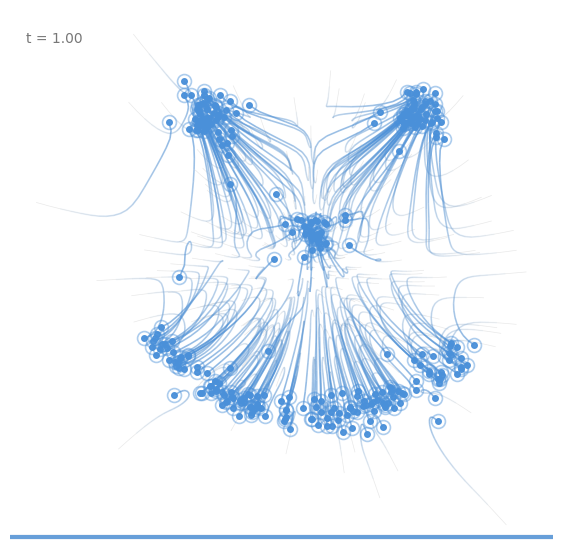

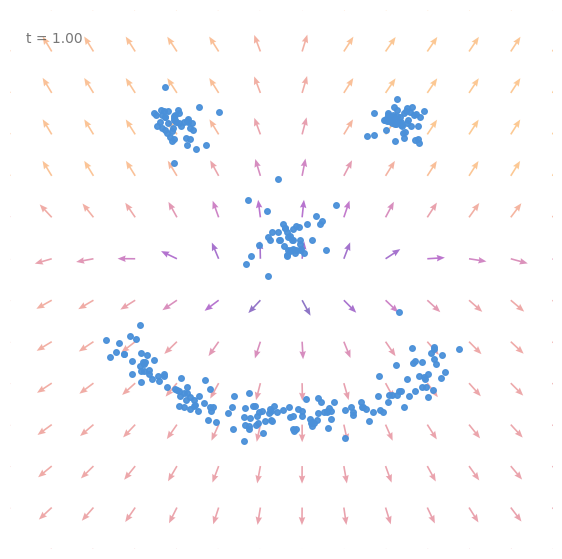

In [8]:
N_SAMPLES = 300
N_STEPS  = 20
GRID_N   = 20
FPS      = 30
DURATION = 7
GRID_N   = 14

x = torch.randn(1000, 2)
n_steps  = N_STEPS
time_steps = torch.linspace(0, 1.0, n_steps + 1)
trajectories = [x.clone()]

with torch.no_grad():
 for i in range(n_steps):
   x = net.step(x, time_steps[i], time_steps[i + 1])
   trajectories.append(x.clone())

trajectories = torch.stack(trajectories).numpy()
visualizing_flow_path(trajectories, False, N_SAMPLES, N_STEPS, FPS, DURATION)
visualize_vector_field(trajectories, False, N_SAMPLES, N_STEPS, FPS, DURATION, GRID_N, time_steps.numpy())


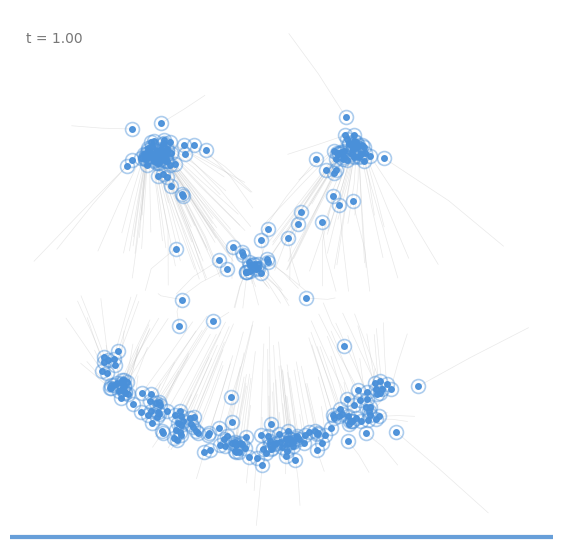

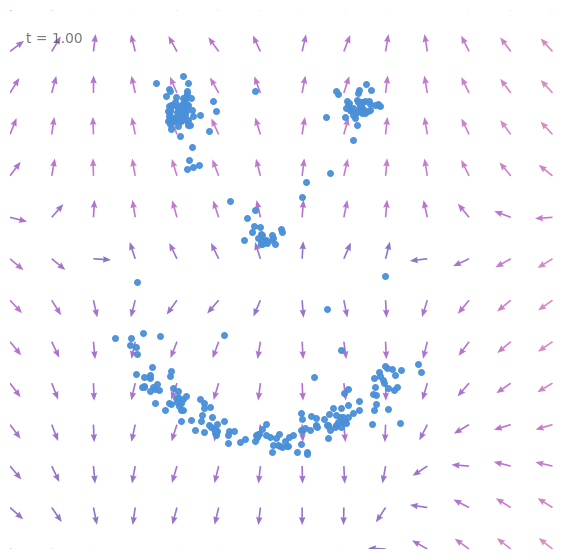

In [9]:
N_SAMPLES = 300
N_STEPS  = 2
GRID_N   = 20
FPS      = 30
DURATION = 7
GRID_N   = 14

x = torch.randn(1000, 2)
n_steps  = N_STEPS
time_steps = torch.linspace(0, 1.0, n_steps + 1)
trajectories = [x.clone()]

with torch.no_grad():
 for i in range(n_steps):
   x = rectified_net.step(x, time_steps[i], time_steps[i + 1])
   trajectories.append(x.clone())

trajectories = torch.stack(trajectories).numpy()
visualizing_flow_path(trajectories, True, N_SAMPLES, N_STEPS, FPS, DURATION)
visualize_vector_field(trajectories, True, N_SAMPLES, N_STEPS, FPS, DURATION, GRID_N, time_steps.numpy())
